In [1]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

API_KEY = ""
ACCOUNT_NAME = "seolwon64"

#QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token=API_KEY,
#    name=ACCOUNT_NAME,
#    overwrite=True,
#    set_as_default=False,
#)

# Load saved credentials
service = QiskitRuntimeService(name="seolwon64")

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
# backend = service.backend("ibm_fez")
print(backend.name)


sampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-09-14 00:23:23,511: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-09-14 00:23:24,072: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-14 00:23:27,401: Using instance: open-instance, plan: open


ibm_fez


In [2]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Alternatively, load a fake backend with generic properties and define a simulator.


noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

# You could also define a simulator-based sampler using a generic backend:
# backend_gen = GenericBackendV2(num_qubits=18)
# sampler_gen = BackendSamplerV2(backend=backend_gen)

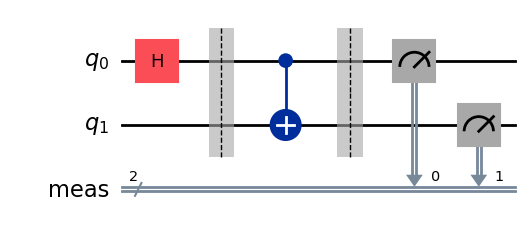

In [3]:
# Step 1: Map

from qiskit import QuantumCircuit

qc = QuantumCircuit(2)


def twobit_function(case: int):
    """
    Generate a valid two-bit function as a `QuantumCircuit`.
    """
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1) # FLIP Q1 WHEN Q0 = 1 CNOT
    if case in [3, 4]:
        f.x(1) # FLIP Q1
    return f


# first, convert oracle circuit (above) to a single gate for drawing purposes. otherwise, the
# circuit is too large to display

# you may edit the number inside "twobit_function()" to select among the four valid functions:
# blackbox = twobit_function(2).to_gate()

# blackbox.label = "$U_f$"

qc.h(0)
qc.barrier()
#CASE 2
qc.compose(twobit_function(2), inplace=True) # INPLACE = TRUE : JUST MODIFY THE EXISTING CIRCUIT, DO NOT RETURN A NEW ONE
qc.measure_all()


qc.draw("mpl")

In [4]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

In [5]:
# Step 3: Run the job on a real quantum computer

job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.meas.get_counts()

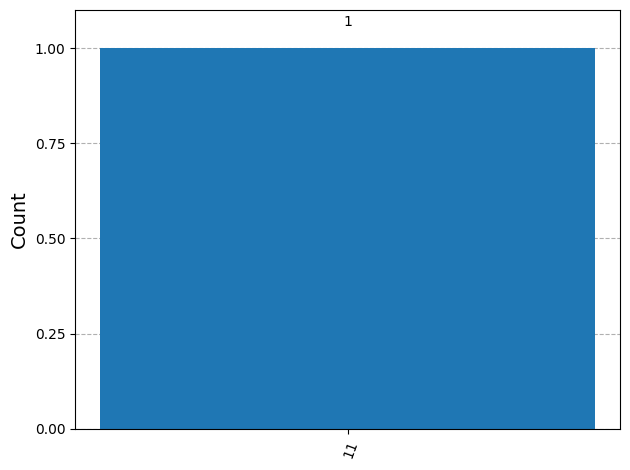

In [6]:
# Step 4: Visualize and analyze results

## Analysis
from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [7]:
"""▶Deutsch's algorithm◀"""

"▶Deutsch's algorithm◀"

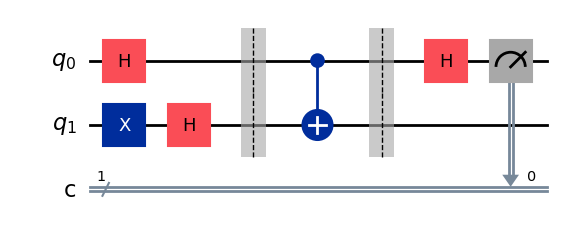

In [8]:
## Deutsch's algorithm:

## Step 1: Map the problem

# first, convert oracle circuit (above) to a single gate for drawing purposes.
# otherwise, the circuit is too large to display
blackbox = twobit_function(
    3
    # you may edit the number (1-4) inside "twobit_function()" to select among the four valid functions
).to_gate()
blackbox.label = "$U_f$"


qc_deutsch = QuantumCircuit(2, 1)

qc_deutsch.x(1)
qc_deutsch.h(range(2))

qc_deutsch.barrier()
qc_deutsch.compose(twobit_function(2), inplace=True)
qc_deutsch.barrier()

qc_deutsch.h(0)
qc_deutsch.measure(0, 0)

qc_deutsch.draw("mpl")

In [9]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_deutsch)

In [10]:
# Step 3: Run the job on a real quantum computer

job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [11]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)
if "1" in counts:
    print("balanced")
else:
    print("constant")

{'1': 1}
balanced


In [12]:
"""▶The Deutsch-Jozsa algorithm◀"""

'▶The Deutsch-Jozsa algorithm◀'

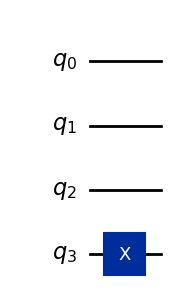

In [13]:
from qiskit import QuantumCircuit
import numpy as np


def dj_function(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """

    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2): # 0 OR 1
        # Flip output qubits with 50% chance
        qc_dj.x(num_qubits) # X GATE
    if np.random.randint(0, 2):
        # return "CONSTANT" circuit with 50% chance.
        return qc_dj 

    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:

    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples -> HALF OF ALL POSSIBLE STATES -> F(X) = 1
        replace=False,  # makes sure states are only sampled once NOT PICKING TWICE
    )
# enumerate : for i, ch in enumerate("abc"):
 #   print(i, ch) -> 0 a / 1 b / 2 c
    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit) # X GATE
        return qc_dj

    for state in on_states: # BALANCED
        # qc_dj.barrier()  # Barriers are added to help visualize how the functions are created.
        # They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}") # FLIP THE CONTROL QUBITS TO 1 EX) 101 -> 111
        qc_dj.mcx(list(range(num_qubits)), num_qubits) # MCX = MULTI-CONTROLLED X -> FLIPS THE TARGET WHEN ALL CONTROLS ARE 1.
        qc_dj = add_cx(qc_dj, f"{state:0b}") # BACK 111 -> 101

    # qc_dj.barrier()

    return qc_dj


n = 3  # number of input qubits

oracle = dj_function(n)

display(oracle.draw("mpl"))

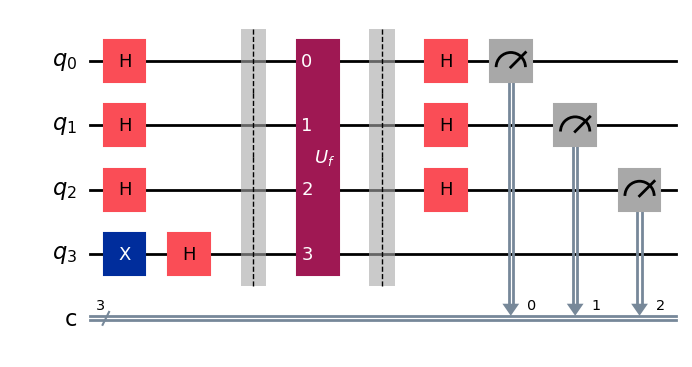

In [14]:
blackbox = oracle.to_gate()
blackbox.label = "$U_f$"


qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1)) # IF N = 3 => H(0) H(1) H(2) H(3) H(4) ONLY IN QISKIT
qc_dj.barrier()
qc_dj.compose(blackbox, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n)) # NOT H IN Q3 : |-> -> |1> : NO INFORMATION
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

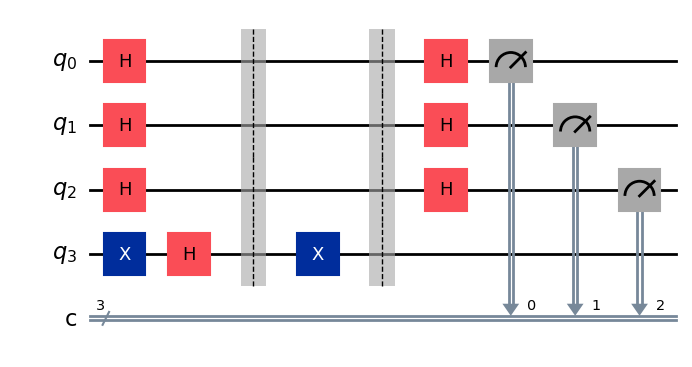

In [15]:
# Step 1: Map the problem FOR DEBUGGING

qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1)) 
qc_dj.barrier()
qc_dj.compose(oracle, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

In [16]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_dj)

In [17]:
# Step 3: Run the job on a real quantum computer

job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [18]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)

if (
    "0" * n in counts
):  # The D-J algorithm returns all zeroes if the function was constant
    print("constant")
else:
    print("balanced")  # anything other than all zeroes means the function is balanced.

{'000': 99, '010': 1}
constant


In [ ]:
"""▶ The Bernstein - Vazirani problem ◀"""

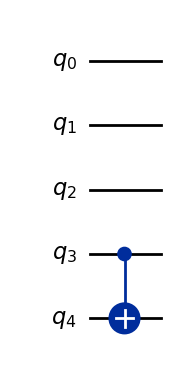

In [19]:
# Step 1: Map the problem


def bv_function(s):
    """
    Create a Bernstein-Vazirani function from a string of 1s and 0s.
    """
    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc


display(bv_function("1000").draw("mpl"))

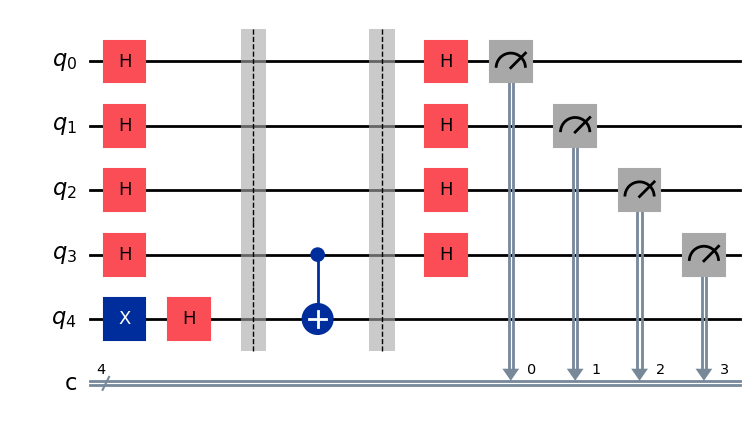

In [20]:
string = "1000"  # secret string that we'll pretend we don't know or have access to
n = len(string)

qc = QuantumCircuit(n + 1, n)
qc.x(n)
qc.h(range(n + 1))
qc.barrier()
# qc.compose(oracle, inplace = True)
qc.compose(bv_function(string), inplace=True)
qc.barrier()
qc.h(range(n))
qc.measure(range(n), range(n))

qc.draw("mpl")

In [21]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

In [22]:
# Step 3: Run the job on a real quantum computer

job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [23]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)

{'1000': 1}
